# Introducción al Análisis Exploratorio de Datos (EDA)

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/AxelSkrauba/applied-ai-engineering/blob/main/notebooks/02_eda/01_introduccion_eda.ipynb)

## Objetivos


- Comprender la importancia del Análisis Exploratorio de Datos (*EDA*, por sus siglas en inglés) en un *pipeline* de Machine Learning.
- Aprender a utilizar herramientas estándar (`pandas`, `seaborn`, `matplotlib`) para la inspección inicial de datos.
- Identificar y tratar problemas comunes del mundo real: datos faltantes (*missing values*) y valores atípicos (*outliers*).
- Extraer intuiciones clínicas/prácticas a partir de las visualizaciones.

## Prerrequisitos


- [Conceptos básicos de Machine Learning](../01_introduccion/01_conceptos_basicos.ipynb) (Recomendado).
- Conocimientos fundamentales de estadística descriptiva (media, mediana, distribuciones).

---
## Configuración del Entorno

In [1]:
# @title *Esta celda clona el repositorio (en Colab) e importa las utilidades comunes*
import sys
import os

# Detectar Google Colab
IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    print("Ejecución en Google Colab. Clonando repositorio...")
    import subprocess
    REPO_NAME = "applied-ai-engineering"
    if not os.path.exists(REPO_NAME):
        subprocess.run(["git", "clone", "https://github.com/AxelSkrauba/applied-ai-engineering.git"], check=True)
    os.chdir(f"/content/{REPO_NAME}")
    sys.path.append(f"/content/{REPO_NAME}")

# Importar utilidades globales
from utils.plots import setup_plot_style
setup_plot_style()

Ejecución en Google Colab. Clonando repositorio...


In [2]:
# Importación de librerías específicas para este notebook
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings('ignore') # Mantenemos los logs limpios

## Introducción Teórica

El **Análisis Exploratorio de Datos (EDA)** es el proceso de investigar, visualizar y comprender las características principales de un conjunto de datos antes de aplicar algoritmos de Machine Learning.

¿Por qué es IMPORTANTE?
- ***Garbage in*, *garbage out*:** Si alimentamos un modelo con datos ruidosos, incompletos o sesgados, sus predicciones no tendrán valor.
- Nos permite descubrir patrones, anomalías y relaciones subyacentes.
- Ayuda a formular hipótesis y a decidir qué transformaciones o modelos serán los más apropiados.

El EDA no es un proceso lineal, sino iterativo. Exploramos, visualizamos, limpiamos y volvemos a explorar.

## Desarrollo e Implementación

### 1. El Problema y los Datos (Contexto)

Para este recorrido, utilizamos un *dataset* clínico (simulado/desidentificado) orientado a la predicción de **Accidentes Cerebrovasculares (ACV)**.
Cada fila representa a un paciente y cada columna una característica (*feature*) demográfica o clínica.

*   `id`: Identificador único.
*   `genero`: "hombre", "mujer" u "otro".
*   `edad`: Edad en años.
*   `hipertension` y `enfermedad_corazon`: Indicadores binarios (0=No, 1=Sí).
*   `casado_alguna_vez`, `tipo_trabajo`, `tipo_residencia`: Variables categóricas sociodemográficas.
*   `nivel_glucosa`, `imc`: Mediciones clínicas numéricas.
*   `estado_fumador`: Historial de tabaquismo.
*   `apoplejia` (**Target**): Variable a predecir. 1 si tuvo ACV, 0 en caso contrario.

### 2. Carga y Exploración Inicial

Primero, cargamos los datos y damos un "vistazo" rápido a su estructura. Usamos `pandas`, la librería por excelencia para el manejo de datos tabulares en Python.

In [4]:
# Esta función engloba código reutilizable para la gestión y carga de los datos
from utils.data import load_dataset

dataset_path = "datasets/acv/datos_acv.csv"

dataset = load_dataset(dataset_path)

# Pandas hace la magia, una carga directa se ve así:
# dataset = pd.read_csv(dataset_path)

Dataset cargado exitosamente con 5110 filas y 12 columnas.


In [5]:
# Primeras 5 filas para verificar que los datos se leyeron correctamente
dataset.head()

,id,genero,edad,hipertension,enfermedad_corazon,casado_alguna_vez,tipo_trabajo,tipo_residencia,nivel_glucosa,imc,estado_fumador,apoplejia
0,9046,hombre,67.0,0,1,1,privado,urbano,228.69,36.6,fumaba,1
1,51676,mujer,61.0,0,0,1,autonomo,rural,202.21,NaN,nunca,1
2,31112,hombre,80.0,0,1,1,privado,rural,105.92,32.5,nunca,1
3,60182,mujer,49.0,0,0,1,privado,urbano,171.23,34.4,fuma,1
4,1665,mujer,79.0,1,0,1,autonomo,rural,174.12,24.0,nunca,1


In [6]:
# Resumen de los tipos de datos y recuento de valores no nulos
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5110 entries, 0 to 5109
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   id                  5110 non-null   int64  
 1   genero              5110 non-null   object 
 2   edad                5110 non-null   float64
 3   hipertension        5110 non-null   int64  
 4   enfermedad_corazon  5110 non-null   int64  
 5   casado_alguna_vez   5110 non-null   int64  
 6   tipo_trabajo        5110 non-null   object 
 7   tipo_residencia     5110 non-null   object 
 8   nivel_glucosa       5110 non-null   float64
 9   imc                 4909 non-null   float64
 10  estado_fumador      5110 non-null   object 
 11  apoplejia           5110 non-null   int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 479.2+ KB


Observamos que algunas columnas son de tipo `object` (strings categóricos), otras `int64` (enteros) y `float64` (decimales).
Además, la columna `imc` tiene 4909 valores no nulos frente a las 5110 filas totales. ¡Tenemos datos faltantes!

In [7]:
# Descriptores estadísticos básicos para las columnas numéricas
dataset.describe()

,id,edad,hipertension,enfermedad_corazon,casado_alguna_vez,nivel_glucosa,imc,apoplejia
count,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,5110.000000,4909.000000,5110.000000
mean,36517.829354,43.226614,0.097456,0.054012,0.656164,106.147677,28.893237,0.048728
std,21161.721625,22.612647,0.296607,0.226063,0.475034,45.283560,7.854067,0.215320
min,67.000000,0.080000,0.000000,0.000000,0.000000,55.120000,10.300000,0.000000
25%,17741.250000,25.000000,0.000000,0.000000,0.000000,77.245000,23.500000,0.000000
50%,36932.000000,45.000000,0.000000,0.000000,1.000000,91.885000,28.100000,0.000000
75%,54682.000000,61.000000,0.000000,0.000000,1.000000,114.090000,33.100000,0.000000
max,72940.000000,82.000000,1.000000,1.000000,1.000000,271.740000,97.600000,1.000000


### 3. Tratamiento de Datos Faltantes (*Missing Values*)

Los modelos de ML matemáticos no saben cómo lidiar con un valor vacío (`NaN` o `Null`). Debemos identificarlos y tomar decisiones informadas sobre qué hacer con ellos.

In [8]:
# Contabilizar valores nulos por columna
dataset.isna().sum()

,0
id,0
genero,0
edad,0
hipertension,0
enfermedad_corazon,0
casado_alguna_vez,0
tipo_trabajo,0
tipo_residencia,0
nivel_glucosa,0
imc,201


Según el contexto de nuestro problema (ver tarjeta del *dataset* en [*ACV Dataset*](https://github.com/AxelSkrauba/applied-ai-engineering/blob/main/datasets/acv/README.md)), en la variable `estado_fumador`, la categoría "desconocido" se utilizó para las entradas donde no había información. **Esto es funcionalmente un dato faltante** disfrazado de categoría. Vamos a exponerlo como tal para tratarlo correctamente.

In [9]:
# Reemplazamos "desconocido" por el valor nulo estándar de numpy (np.nan)
dataset['estado_fumador'] = dataset['estado_fumador'].replace('desconocido', np.nan)

# Calculamos el porcentaje de valores perdidos
miss_val_pct = dataset.isnull().sum() / len(dataset) * 100
print("Porcentaje de valores faltantes:")
print(miss_val_pct[miss_val_pct > 0].apply(lambda x: f"{x:.2f}%"))

Porcentaje de valores faltantes:
imc                3.93%
estado_fumador    30.22%
dtype: object


Para variables numéricas con bajo porcentaje de faltantes (como el `imc`, ~3.9%), una práctica común es **imputar** (rellenar) esos huecos con la **mediana** de la distribución, ya que es más robusta a *outliers* que la media.

Para variables categóricas con un alto porcentaje (como `estado_fumador`, ~30%), la decisión es más difícil. Podríamos imputar con la moda (el más frecuente), pero estaríamos sesgando mucho los datos. En este ejemplo didáctico, optaremos por **eliminar** las filas que no tengan esta información.

*Nota: En un escenario real estricto, descartar el 30% de los datos duele (en sentido figurado, por las dudas...). Se podrían usar técnicas avanzadas de imputación (ej: predecir el estado fumador basado en la edad y enfermedades).*

In [10]:
# 1. Imputación de IMC con la mediana
mediana_imc = dataset['imc'].median()
dataset['imc'] = dataset['imc'].fillna(mediana_imc)

# 2. Descarte de filas con 'estado_fumador' nulo
dataset = dataset.dropna(subset=['estado_fumador'])

print(f"Filas restantes después de la limpieza: {len(dataset)}")
print(f"Valores nulos restantes:\n{dataset.isna().sum().sum()}")

Filas restantes después de la limpieza: 3566
Valores nulos restantes:
0


### 4. Análisis de Distribuciones y Desbalance

Vamos a explorar cómo se distribuyen nuestras variables categóricas, prestando especial atención a nuestra variable objetivo (`apoplejia`).

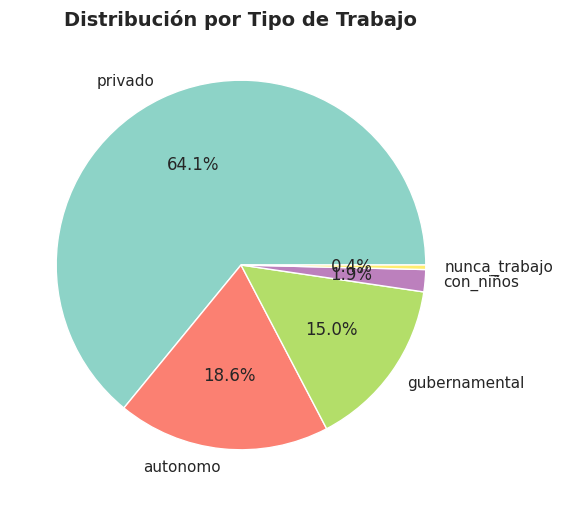

In [11]:
# Gráfico de pastel para el estado laboral
plt.figure(figsize=(6, 6))
dataset['tipo_trabajo'].value_counts().plot.pie(autopct='%1.1f%%', cmap='Set3', ylabel='')
plt.title('Distribución por Tipo de Trabajo')
plt.show()

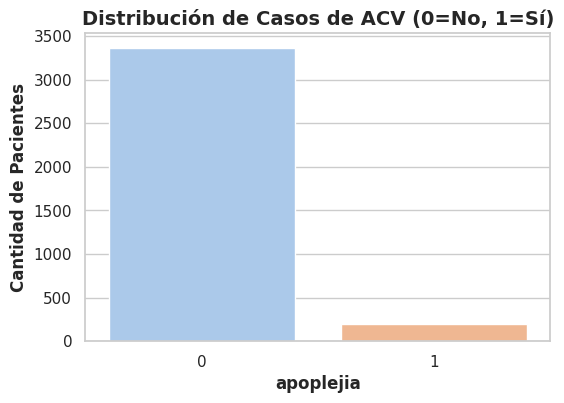

Casos positivos de ACV: 202 (5.66%)


In [12]:
# Verificamos el balance de nuestra variable a predecir
plt.figure(figsize=(6, 4))
sns.countplot(data=dataset, x='apoplejia', palette='pastel')
plt.title('Distribución de Casos de ACV (0=No, 1=Sí)')
plt.ylabel('Cantidad de Pacientes')
plt.show()

casos_positivos = (dataset['apoplejia'] == 1).sum()
pct_positivos = casos_positivos / len(dataset) * 100
print(f"Casos positivos de ACV: {casos_positivos} ({pct_positivos:.2f}%)")

**¡Alerta de Desbalance!** ⚠️

Notamos que los casos positivos (ACV) representan una fracción mínima del *dataset* (apenas un ~5.6%). Este es un escenario muy común en salud, detección de fraudes y mantenimiento predictivo.
Si entrenamos un modelo así, probablemente aprenderá a predecir siempre "0" y logrará un 94% de precisión (Accuracy), siendo completamente inútil. En fases posteriores (Modelado) abordaremos técnicas como el submuestreo o SMOTE para lidiar con esto.

### 5. Detección de Valores Atípicos (*Outliers*)

Los *outliers* son valores que se desvían drásticamente del resto de la distribución. Pueden ser errores de carga de datos o anomalías reales muy raras. Usamos diagramas de caja (*Boxplots*) para detectarlos visualmente en las variables continuas.

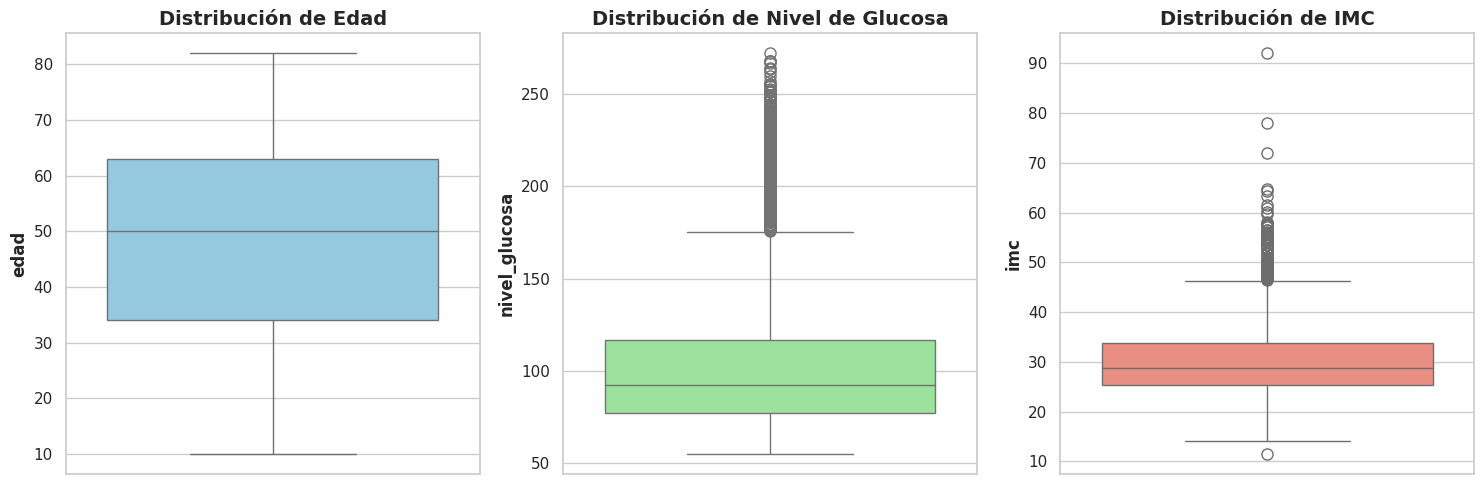

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

sns.boxplot(y=dataset['edad'], ax=axes[0], color='skyblue')
axes[0].set_title('Distribución de Edad')

sns.boxplot(y=dataset['nivel_glucosa'], ax=axes[1], color='lightgreen')
axes[1].set_title('Distribución de Nivel de Glucosa')

sns.boxplot(y=dataset['imc'], ax=axes[2], color='salmon')
axes[2].set_title('Distribución de IMC')

plt.tight_layout()
plt.show()

Observamos que no hay *outliers* evidentes en `edad`, pero sí muchos valores extremos altos en `nivel_glucosa` e `imc`.
*   Un `imc` cercano a 80-90 es biológicamente extremo (aunque posible en obesidad mórbida severa), pero podría ser un error tipográfico.
*   Un nivel de glucosa superior a 200 indica diabetes severa, lo cual es real y un fuerte factor de riesgo para ACV, por lo que **no deberíamos eliminarlos ciegamente**.

Para este ejercicio, filtramos (a modo de ejemplo) solo los valores de `imc` extremadamente dudosos (> 60).

In [14]:
# Descarte condicional
dataset = dataset[dataset['imc'] <= 60]
print(f"Filas tras eliminar outliers de IMC: {len(dataset)}")

Filas tras eliminar outliers de IMC: 3557


### 6. Relaciones entre Variables (Correlación)

Para entender cómo se relacionan las variables entre sí, podemos usar una matriz de correlación. Sin embargo, matemáticamente la correlación estándar (Pearson) se aplica a valores numéricos. Por lo tanto, debemos transformar nuestras variables categóricas (*strings*) a números temporales.

#### Tipos de Correlación (Mini Teoría)
- **Pearson**: Mide relaciones lineales. Ideal para distribuciones normales continuas.
- **Spearman**: Basado en rangos. Útil para relaciones monótonas (si uno sube, el otro también, pero no necesariamente en línea recta) o si hay muchos outliers.
- **Kendall**: Similar a Spearman, pero más robusto cuando el dataset es pequeño o hay muchos "empates" de valores.

Vamos a codificar rápidamente las categóricas usando `LabelEncoder` de `scikit-learn`.

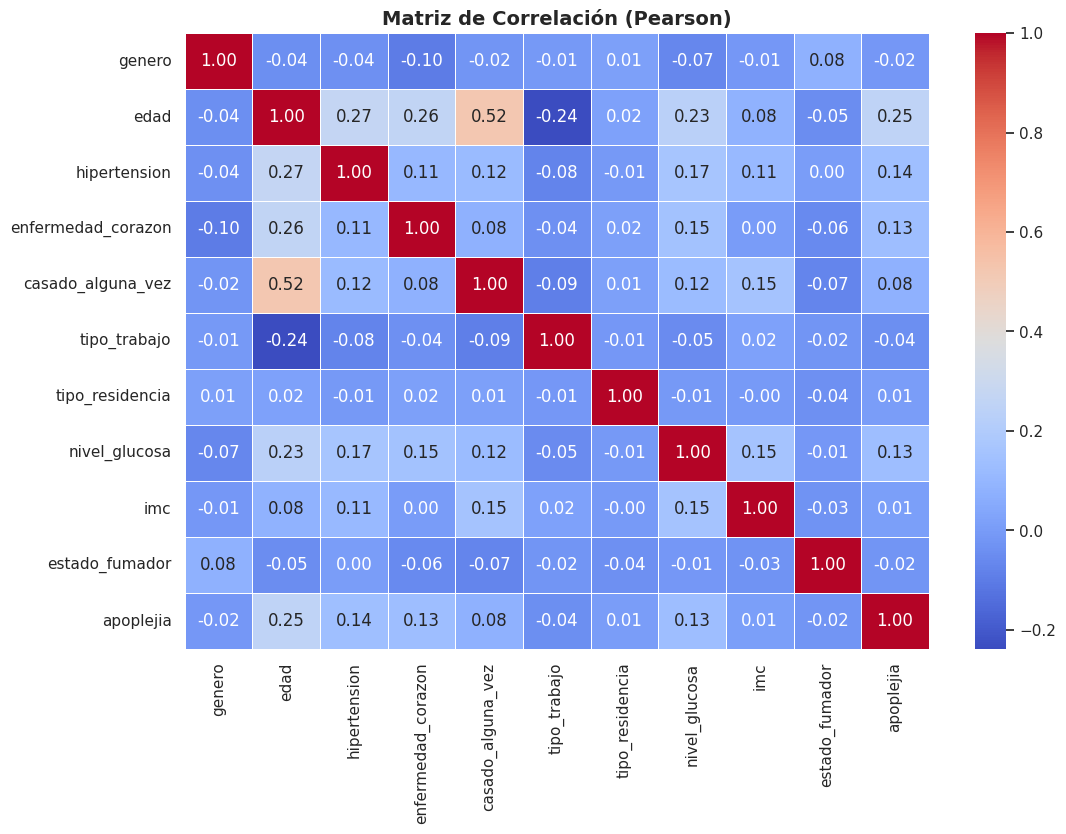

In [15]:
from sklearn.preprocessing import LabelEncoder

dataset_encoded = dataset.copy()
le = LabelEncoder()

# Eliminamos la columna ID porque no tiene valor predictivo
dataset_encoded = dataset_encoded.drop(columns=['id'])

# Codificamos las variables categóricas
for col in dataset_encoded.select_dtypes(include=['object', 'category', 'string']).columns:
    dataset_encoded[col] = le.fit_transform(dataset_encoded[col])

# Mostramos el mapa de calor con el coeficiente de Pearson
plt.figure(figsize=(12, 8))
sns.heatmap(dataset_encoded.corr(method='pearson'), annot=True, fmt=".2f", cmap='coolwarm', linewidths=0.5)
plt.title('Matriz de Correlación (Pearson)')
plt.show()

En el mapa de calor, buscamos valores cercanos a 1 (correlación positiva fuerte) o -1 (correlación negativa fuerte).
*   Observamos una alta correlación (0.68) entre la `edad` y `casado_alguna_vez`. ¡Tiene todo el sentido lógico!
*   La variable objetivo `apoplejia` tiene sus mayores correlaciones positivas con la `edad` (0.24), el `nivel_glucosa` (0.13) y la presencia de `hipertension` (0.14) o `enfermedad_corazon` (0.14). Esto nos confirma que estas variables serán predictoras importantes para nuestros futuros modelos.

**NOTA**: para entender mejor las correlaciones, explorar el notebook [Análisis de Correlación y Asociación](03_analisis_correlacion_y_asociacion.ipynb)

## Resultados y Discusión

A partir de este EDA básico, hemos concluido que:
1. Nuestro *dataset* sufre de un **fuerte desbalance de clases**, requiriendo atención especial en la fase de modelado.
2. Identificamos y tratamos datos faltantes de manera fundamentada (imputación por mediana para numéricos, descarte para categóricos).
3. Confirmamos mediante correlaciones que factores biológicos como la edad, la glucosa y condiciones cardíacas preexistentes están ligados a la probabilidad de un ACV en nuestros datos.
4. Identificamos que variables como el `id` no aportan información y solo introducen ruido.

## Conexiones y Próximos Pasos
- ➡️ **Siguiente:** [Feature Engineering y Limpieza de Datos](02_feature_engineering_y_limpieza.ipynb).
- 🔄 **Relacionado:** Con el dataset limpio, estamos listos para entender qué hacen los modelos con esto [Introducción a la Clasificación](../03_machine_learning/01_introduccion_clasificacion.ipynb).

## Referencias
1. Dataset ACV: Healthcare Dataset Stroke Data (Kaggle).
2. [Documentación Oficial de Pandas](https://pandas.pydata.org/docs/)
3. [Documentación de Seaborn para Visualización Estadística](https://seaborn.pydata.org/)

---
## Entorno de Ejecución

In [16]:
from utils.environment import environment_table
environment_table()

Package,Version
Python,3.12.12
Platform,Linux-6.6.113+-x86_64-with-glibc2.35
IPython,7.34.0
ipywidgets,7.7.1
joblib,1.5.3
matplotlib,3.10.0
numpy,2.0.2
pandas,2.2.2
scipy,1.16.3
seaborn,0.13.2
